In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Normal inverse CDF (ppf): scipy preferred, fallback to statistics ----------
try:
    from scipy.stats import norm
    def norm_ppf(p):
        return norm.ppf(p)
except Exception:
    from statistics import NormalDist
    _ND = NormalDist()
    def norm_ppf(p):
        p = np.asarray(p, dtype=float)
        return np.vectorize(_ND.inv_cdf)(p)

# ---------- Huber loss ----------
def huber_loss(u, tau):
    u = np.asarray(u, dtype=float)
    a = np.abs(u)
    out = np.empty_like(a)
    mask = (a <= tau)
    out[mask] = 0.5 * a[mask]**2
    out[~mask] = tau * (a[~mask] - 0.5 * tau)
    return out

# ---------- abs_normal_q ----------
def abs_normal_q(c_seg, total_node, alpha=1.0, power=3.0):
    n = int(total_node)
    c_seg = int(c_seg)

    if c_seg < 1:
        raise ValueError("c_seg must be >= 1")
    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in (0,1]")
    if power <= 1:
        raise ValueError("power must be > 1")

    n_max = max(1, int(np.floor(alpha * n)))
    if n_max < c_seg:
        raise ValueError("alpha*n is too small: n_max < c_seg")

    t = np.linspace(0.0, 1.0, c_seg)                 # length = c_seg
    g = 1.0 - (1.0 - t)**power                       # dec gaps: front big, back small
    i_idx = 1 + np.floor((n_max - 1) * g).astype(int)

    p = 0.5 + i_idx / (2.0 * (n + 1.0))
    q = norm_ppf(p)
    return i_idx, q



# ---------- modified_huber (vectorized) ----------
def modified_huber(z, knot_vec, total_node):
    z = np.asarray(z, dtype=float)
    knot_vec = np.asarray(knot_vec, dtype=float)

    c_seg = int(len(knot_vec) - 1)
    z_abs = np.abs(z)

    tau0 = knot_vec[0]
    tau_vec = np.empty(c_seg + 1, dtype=float)
    tau_vec[0] = tau0

    u = np.arange(1, c_seg + 1, dtype=float) / (float(total_node) + 1.0)
    tau_vec[1:] = norm_ppf((u + 1.0) / 2.0) + tau0

    b = np.empty(c_seg + 1, dtype=float)
    b[0] = -0.5 * tau0**2
    for i in range(1, c_seg + 1):
        b[i] = tau_vec[i-1] * knot_vec[i] + b[i-1] - tau_vec[i] * knot_vec[i]

    rho = np.empty_like(z_abs)

    mask0 = (z_abs <= knot_vec[0])
    mask_tail = (z_abs > knot_vec[-1])
    mask_mid = ~(mask0 | mask_tail)

    rho[mask0] = 0.5 * z_abs[mask0]**2
    rho[mask_tail] = tau_vec[-1] * knot_vec[-1] + b[-1]

    if np.any(mask_mid):
        k = np.searchsorted(knot_vec, z_abs[mask_mid], side="left") - 1
        rho[mask_mid] = tau_vec[k] * z_abs[mask_mid] + b[k]

    return rho

def rho_tau_lambda(u, tau, lam):
    """
    ρ_{τ,λ}(u) =
      0.5*u^2,                                        if |u| <= τ
      (λ+τ^2)/2 * [1 - λ/(λ+τ^2) * exp(-(u^2-τ^2)/λ)], if |u| >  τ

    Parameters
    ----------
    u   : float or array-like
    tau : float, τ > 0
    lam : float, λ > 0

    Returns
    -------
    rho : float or np.ndarray
    """
    tau = float(tau)
    lam = float(lam)
    if tau <= 0 or lam <= 0:
        raise ValueError("tau and lam must be positive.")

    u = np.asarray(u, dtype=float)
    u2 = u * u
    tau2 = tau * tau

    out = np.empty_like(u2)
    mask = np.abs(u) <= tau

    # |u| <= tau
    out[mask] = 0.5 * u2[mask]

    # |u| > tau (use a numerically stable equivalent form)
    # (λ+τ^2)/2 - (λ/2) * exp(-(u^2-τ^2)/λ)
    out[~mask] = 0.5 * (lam + tau2) - 0.5 * lam * np.exp(-(u2[~mask] - tau2) / lam)

    return float(out) if out.shape == () else out



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


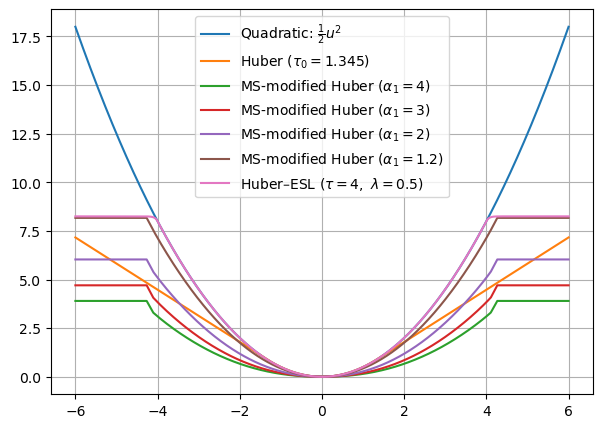

In [2]:
# ---------------------- Build inputs ----------------------
x = np.linspace(-6, 6, 2001)
knot_vec1 = abs_normal_q(49999 + 1, total_node=50000, alpha=1.0, power=4.0)[1]
knot_vec2 = abs_normal_q(49999 + 1, total_node=50000, alpha=1.0, power=3.0)[1]
knot_vec3 = abs_normal_q(49999 + 1, total_node=50000, alpha=1.0, power=2.0)[1]
knot_vec4 = abs_normal_q(49999 + 1, total_node=50000, alpha=1.0, power=1.2)[1]
# ---------------------- Compute curves ----------------------
y_quad    = 0.5 * x**2
y_huber   = huber_loss(x, tau=1.345)
y_mhuber1 = modified_huber(x, knot_vec=knot_vec1, total_node=50000)
y_mhuber2 = modified_huber(x, knot_vec=knot_vec2, total_node=50000)
y_mhuber3 = modified_huber(x, knot_vec=knot_vec3, total_node=50000)
y_mhuber4 = modified_huber(x, knot_vec=knot_vec4, total_node=50000)
y_rhotl   = rho_tau_lambda(x, tau=4, lam=0.5)

# ---------------------- One figure, one axes ----------------------
plt.figure(figsize=(7, 5))

plt.plot(x, y_quad,    label=r"Quadratic: $\frac{1}{2}u^2$")
plt.plot(x, y_huber,   label=r"Huber ($\tau_0=1.345$)")
plt.plot(x, y_mhuber1, label=r"MS-modified Huber ($\alpha_1=4$)")
plt.plot(x, y_mhuber2, label=r"MS-modified Huber ($\alpha_1=3$)")
plt.plot(x, y_mhuber3, label=r"MS-modified Huber ($\alpha_1=2$)")
plt.plot(x, y_mhuber4, label=r"MS-modified Huber ($\alpha_1=1.2$)")
plt.plot(x, y_rhotl,   label=r"Huber–ESL ($\tau=4,\ \lambda=0.5$)")

#plt.xlabel("x")
#plt.ylabel("loss")
#plt.title("Loss functions (6 curves)")
plt.grid(True)
plt.legend()
#plt.show()
plt.savefig("loss_compare.eps", dpi=300, bbox_inches="tight")